# Assignment 4 - Pokemon Analysis

**IEM.DAM2, SS 2026**

This notebook works through the five tasks of the assignment:

1. **Distance function** - design a meaningful pairwise distance over the Pokedex.
2. **Clustering** - run a clustering algorithm on top of that distance and tune it with the silhouette score.
3. **Visualization** - project to 2D with tSNE and UMAP and color the points by cluster.
4. **Outlier detection** - flag unusual Pokemon with LOF, Isolation Forest and HDBSCAN noise.
5. **Discussion** - reflect on what worked and what could be improved.

Dataset: `pokedex.csv` (898 Pokemon, six base stats, height/weight, 17 one-hot type columns, thumbnails).

## Setup

Imports and a couple of small helpers. `umap-learn` and `hdbscan` are optional - the notebook degrades gracefully if they are missing.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")

OUT = Path("figures")
OUT.mkdir(exist_ok=True)

## 1. Load the data

`height` and `weight` are stored as strings (`"0.7 m"`, `"6.9 kg"`), so we parse the leading number into numeric columns. Everything else is already numeric or one-hot.

In [2]:
def parse_number(s):
    m = re.search(r"([\d.]+)", str(s))
    return float(m.group(1)) if m else np.nan

df = pd.read_csv("pokedex.csv")
df["height_m"] = df["height"].apply(parse_number)
df["weight_kg"] = df["weight"].apply(parse_number)

STAT_COLS = ["HP", "attack", "defense", "sp. attack", "sp. defense", "speed"]
SIZE_COLS = ["height_m", "weight_kg"]
TYPE_COLS = [c for c in df.columns if c.startswith("type_")]

print(f"{len(df)} Pokemon, {df.shape[1]} columns")
print(f"Type columns ({len(TYPE_COLS)}): {[t.replace('type_', '') for t in TYPE_COLS]}")
df.head()

898 Pokemon, 33 columns
Type columns (17): ['fire', 'water', 'electric', 'grass', 'ice', 'fighting', 'poison', 'ground', 'flying', 'psychic', 'bug', 'rock', 'ghost', 'dragon', 'dark', 'steel', 'fairy']


,id,name,HP,attack,defense,sp. attack,sp. defense,speed,species,description,...,type_psychic,type_bug,type_rock,type_ghost,type_dragon,type_dark,type_steel,type_fairy,height_m,weight_kg
0,1,Bulbasaur,45,49,49,65,65,45,Seed Pokémon,Bulbasaur can be seen napping in bright sunlig...,...,0,0,0,0,0,0,0,0,0.7,6.9
1,2,Ivysaur,60,62,63,80,80,60,Seed Pokémon,There is a bud on this Pokémon’s back. To supp...,...,0,0,0,0,0,0,0,0,1.0,13.0
2,3,Venusaur,80,82,83,100,100,80,Seed Pokémon,There is a large flower on Venusaur’s back. Th...,...,0,0,0,0,0,0,0,0,2.0,100.0
3,4,Charmander,39,52,43,60,50,65,Lizard Pokémon,The flame that burns at the tip of its tail is...,...,0,0,0,0,0,0,0,0,0.6,8.5
4,5,Charmeleon,58,64,58,80,65,80,Flame Pokémon,Charmeleon mercilessly destroys its foes using...,...,0,0,0,0,0,0,0,0,1.1,19.0


## Task 1 - Distance function

A Pokemon is described by three very different kinds of attributes, so a single metric on the raw feature vector doesn't make sense. Instead we build **three normalized distance blocks** and combine them with weights.

| Block | Features | Metric | Why |
| --- | --- | --- | --- |
| **Stats** | 6 base stats (HP, Atk, Def, SpA, SpD, Spe) | standardized Euclidean | continuous, comparable magnitudes after z-scoring |
| **Types** | 17 one-hot type columns | Jaccard | set similarity; "water+ice" should be close to "water+flying" but far from "fire+rock" |
| **Size** | height, weight | standardized Euclidean on `log1p` values | heavy-tailed; log dampens Wailord-style outliers dominating the metric |

Each block is rescaled into roughly `[0, 1]` and then combined as

$$
D = w_{\text{stats}}\, D_{\text{stats}} + w_{\text{types}}\, D_{\text{types}} + w_{\text{size}}\, D_{\text{size}}
$$

Defaults `(0.5, 0.4, 0.1)` give stats the most say (they're the richest signal), types a strong secondary vote, and size a small nudge.

In [3]:
def build_distance_matrix(df, w_stats=0.5, w_types=0.4, w_size=0.1):
    # Stats - standardized Euclidean
    stats_z = StandardScaler().fit_transform(df[STAT_COLS].to_numpy(float))
    d_stats = pairwise_distances(stats_z, metric="euclidean")
    d_stats /= d_stats.max() or 1.0

    # Types - Jaccard on one-hot rows
    d_types = pairwise_distances(df[TYPE_COLS].to_numpy(int), metric="jaccard")

    # Size - log-scaled then standardized Euclidean
    size_z = StandardScaler().fit_transform(np.log1p(df[SIZE_COLS].to_numpy(float)))
    d_size = pairwise_distances(size_z, metric="euclidean")
    d_size /= d_size.max() or 1.0

    D = w_stats * d_stats + w_types * d_types + w_size * d_size
    np.fill_diagonal(D, 0.0)
    return (D + D.T) / 2  # enforce symmetry against fp noise

D = build_distance_matrix(df)
print(f"Distance matrix: shape={D.shape}")
print(f"min={D.min():.3f}, mean={D.mean():.3f}, max={D.max():.3f}")

Distance matrix: shape=(898, 898)
min=0.000, mean=0.516, max=0.945


### Sanity check: nearest neighbours of a few Pokemon

A good distance puts evolutionary lines and same-type Pokemon close together. Let's spot-check.

In [4]:
def neighbours(name, k=5):
    i = df.index[df["name"] == name][0]
    order = np.argsort(D[i])
    return df.iloc[order[1:k + 1]][["name"] + STAT_COLS].assign(distance=D[i, order[1:k + 1]])

for n in ["Bulbasaur", "Charizard", "Pikachu", "Snorlax"]:
    print(f"\nNearest neighbours of {n}:")
    print(neighbours(n).to_string(index=False))


Nearest neighbours of Bulbasaur:
      name  HP  attack  defense  sp. attack  sp. defense  speed  distance
    Oddish  45      50       55          75           65     30  0.029908
     Gloom  60      65       70          85           75     40  0.054419
     Budew  40      30       35          50           70     55  0.054882
   Ivysaur  60      62       63          80           80     60  0.056007
Bellsprout  50      75       35          70           30     40  0.069003

Nearest neighbours of Charizard:
       name  HP  attack  defense  sp. attack  sp. defense  speed  distance
    Moltres  90     100       90         125           85     90  0.045345
   Oricorio  75      70       70          98           70     93  0.062723
 Talonflame  78      81       71          74           69    126  0.075614
Fletchinder  62      73       55          56           52     84  0.116144
      Ho-Oh 106     130       90         110          154     90  0.144134

Nearest neighbours of Pikachu:
      

## Task 2 - Clustering

Since we already have a precomputed distance matrix, the natural choice is **agglomerative clustering with average linkage** - it consumes the matrix directly and is robust on non-Euclidean distances. We sweep `k` from 3 to 12 and pick the `k` with the best silhouette score on the precomputed distance.

We also run **HDBSCAN** (density-based) as a comparison: it can discover an arbitrary number of clusters and explicitly labels points it can't place as noise, which is useful for the outlier task later.

In [5]:
scores = {}
best_k, best_sil, best_labels = None, -1, None
for k in range(3, 13):
    labels_k = AgglomerativeClustering(
        n_clusters=k, metric="precomputed", linkage="average"
    ).fit_predict(D)
    sil = silhouette_score(D, labels_k, metric="precomputed")
    scores[k] = sil
    if sil > best_sil:
        best_k, best_sil, best_labels = k, sil, labels_k

labels = best_labels
print(f"Best k = {best_k} (silhouette = {best_sil:.4f})\n")
for k, s in scores.items():
    print(f"  k={k:>2}: silhouette={s:.4f}" + ("  <- best" if k == best_k else ""))

Best k = 12 (silhouette = 0.2551)

  k= 3: silhouette=0.0677
  k= 4: silhouette=0.0682
  k= 5: silhouette=0.0689
  k= 6: silhouette=0.0935
  k= 7: silhouette=0.1442
  k= 8: silhouette=0.1576
  k= 9: silhouette=0.1833
  k=10: silhouette=0.2065
  k=11: silhouette=0.2147
  k=12: silhouette=0.2551  <- best


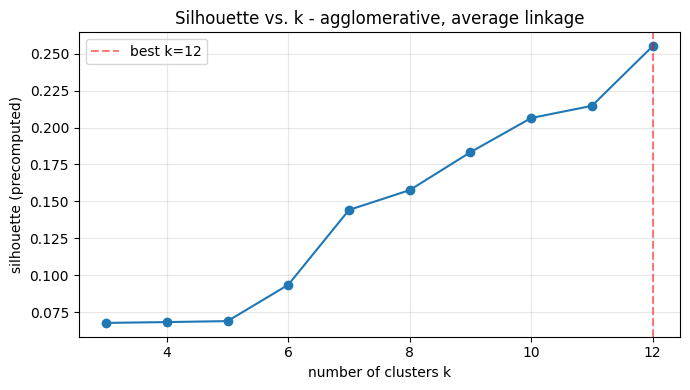

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(scores.keys()), list(scores.values()), marker="o")
ax.axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"best k={best_k}")
ax.set_xlabel("number of clusters k")
ax.set_ylabel("silhouette (precomputed)")
ax.set_title("Silhouette vs. k - agglomerative, average linkage")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### HDBSCAN as a comparison

HDBSCAN doesn't need a `k` - we just give it a minimum cluster size. Points that don't fit get label `-1` (noise), which we'll reuse for outlier detection.

In [7]:
try:
    import hdbscan
    hdb_labels = hdbscan.HDBSCAN(
        metric="precomputed", min_cluster_size=15, min_samples=5
    ).fit_predict(D.astype(np.float64))
    n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    n_noise = int((hdb_labels == -1).sum())
    print(f"HDBSCAN: {n_clusters} clusters, {n_noise} noise points")
except ImportError:
    hdb_labels = None
    print("hdbscan not installed - skipping (pip install hdbscan)")

HDBSCAN: 14 clusters, 367 noise points


### What's inside each cluster?

A quick profile: cluster size, average stat total, and the most common type tags. This is what we'll be coloring in the 2D plots.

In [8]:
df_c = df.copy()
df_c["cluster"] = labels
df_c["stat_total"] = df_c[STAT_COLS].sum(axis=1)

rows = []
for c, sub in df_c.groupby("cluster"):
    top_types = sub[TYPE_COLS].sum().sort_values(ascending=False).head(3)
    rows.append({
        "cluster": c,
        "size": len(sub),
        "avg_stat_total": round(sub["stat_total"].mean(), 1),
        "top_types": ", ".join(t.replace("type_", "") for t in top_types.index),
        "example": ", ".join(sub["name"].head(3).tolist()),
    })
pd.DataFrame(rows)

,cluster,size,avg_stat_total,top_types,example
0,0,327,402.7,"grass, flying, fire","Bulbasaur, Ivysaur, Venusaur"
1,1,72,426.9,"ground, rock, steel","Sandshrew, Sandslash, Diglett"
2,2,135,416.0,"water, ice, rock","Squirtle, Wartortle, Blastoise"
3,3,36,411.7,"fairy, water, dark","Clefairy, Clefable, Jigglypuff"
4,4,41,502.4,"dragon, flying, ghost","Dratini, Dragonair, Dragonite"
5,5,67,450.1,"psychic, fairy, grass","Abra, Kadabra, Alakazam"
6,6,69,407.1,"fire, psychic, steel","Rattata, Raticate, Meowth"
7,7,1,505.0,"rock, bug, fire",Shuckle
8,8,49,434.0,"electric, bug, steel","Pikachu, Raichu, Magnemite"
9,9,50,450.6,"fighting, dark, grass","Mankey, Primeape, Poliwrath"


## Task 3 - 2D visualization with tSNE and UMAP

Both algorithms accept a precomputed distance matrix, so we can feed `D` straight in. The point of the plots is to **eyeball whether the cluster labels look like genuine structure** or whether the embedding tells a different story.

Parameter notes:
- **tSNE** `perplexity=30` is a reasonable default for ~900 points; lower values fragment, higher values blur.
- **UMAP** `n_neighbors=20`, `min_dist=0.1` produces tighter, more cluster-like blobs than the defaults.

In [9]:
tsne_emb = TSNE(
    n_components=2, metric="precomputed", init="random",
    perplexity=30, random_state=42,
).fit_transform(D)

try:
    import umap
    umap_emb = umap.UMAP(
        n_components=2, metric="precomputed",
        n_neighbors=20, min_dist=0.1, random_state=42,
    ).fit_transform(D)
except ImportError:
    umap_emb = None
    print("umap-learn not installed - skipping UMAP (pip install umap-learn)")

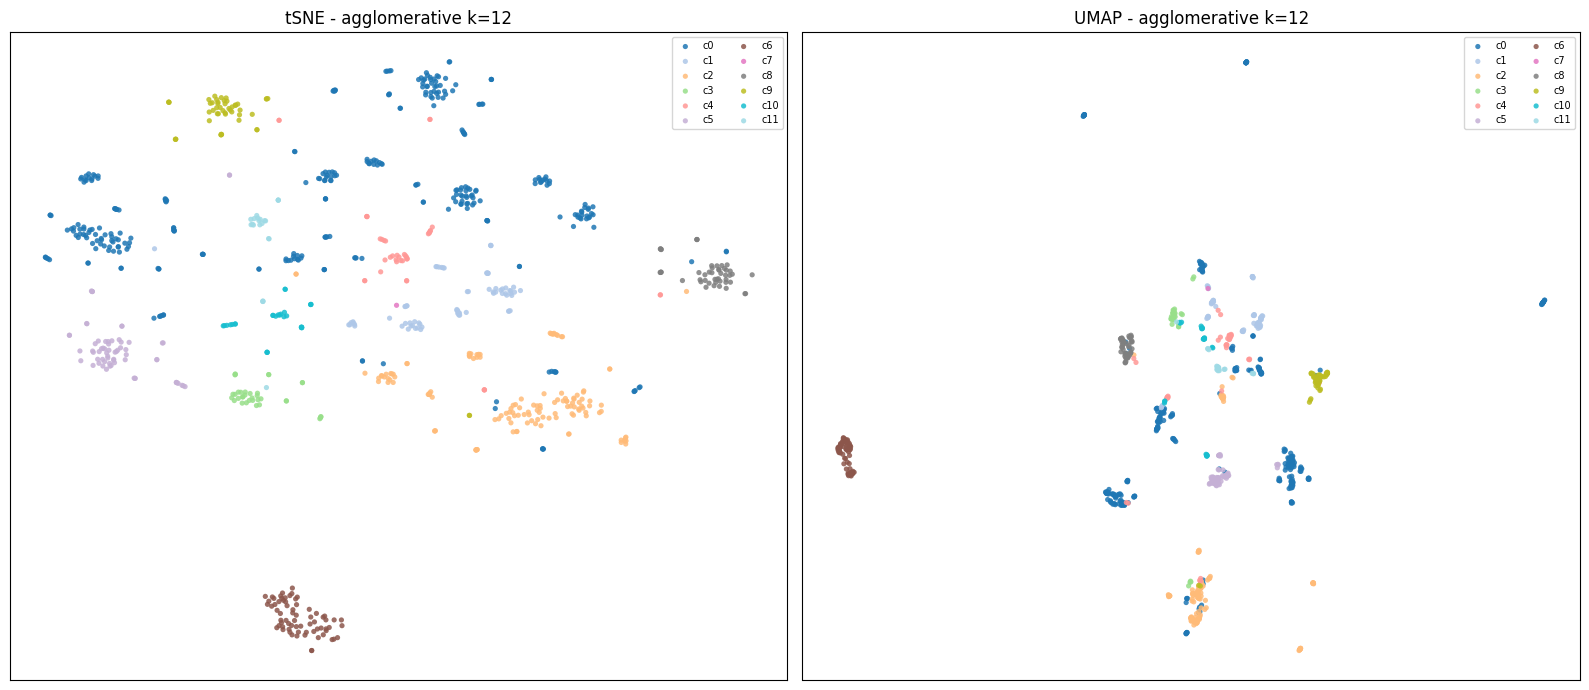

In [10]:
def scatter(ax, emb, labels, title, names=None, outliers=None):
    labels = np.asarray(labels)
    uniq = sorted(set(labels))
    cmap = plt.get_cmap("tab20", max(len(uniq), 1))
    for i, lab in enumerate(uniq):
        mask = labels == lab
        color = "lightgrey" if lab == -1 else cmap(i)
        name = "noise" if lab == -1 else f"c{lab}"
        ax.scatter(emb[mask, 0], emb[mask, 1], s=14, c=[color],
                   label=name, alpha=0.85, edgecolors="none")
    if outliers is not None:
        ax.scatter(emb[outliers, 0], emb[outliers, 1], s=70,
                   facecolors="none", edgecolors="red", linewidths=1.5,
                   label="outlier")
        if names is not None:
            for i in outliers:
                ax.annotate(names[i], (emb[i, 0], emb[i, 1]),
                            fontsize=7, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=7, ncol=2)

n_panels = 2 if umap_emb is not None else 1
fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 7))
if n_panels == 1:
    axes = [axes]
scatter(axes[0], tsne_emb, labels, f"tSNE - agglomerative k={best_k}")
if umap_emb is not None:
    scatter(axes[1], umap_emb, labels, f"UMAP - agglomerative k={best_k}")
plt.tight_layout()
plt.savefig(OUT / "embeddings_agglom.png", dpi=130)
plt.show()

Same embeddings, this time colored by **HDBSCAN** labels (noise points are grey). Compare the layout to the agglomerative panels above - HDBSCAN tends to find fewer, denser groups and leaves a long tail of unusual Pokemon as noise.

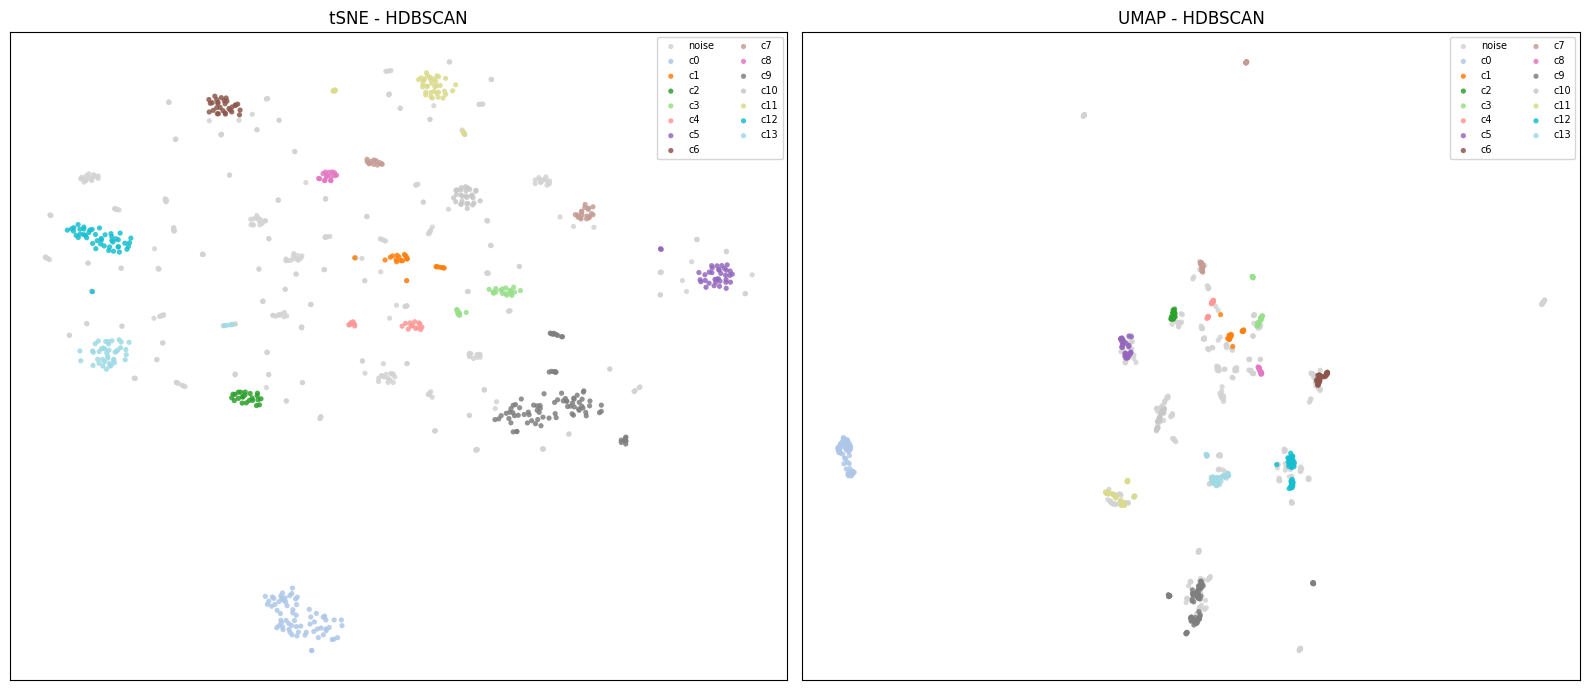

In [11]:
if hdb_labels is not None:
    fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 7))
    if n_panels == 1:
        axes = [axes]
    scatter(axes[0], tsne_emb, hdb_labels, "tSNE - HDBSCAN")
    if umap_emb is not None:
        scatter(axes[1], umap_emb, hdb_labels, "UMAP - HDBSCAN")
    plt.tight_layout()
    plt.savefig(OUT / "embeddings_hdbscan.png", dpi=130)
    plt.show()

## Task 4 - Outlier detection

We use three complementary lenses and look for **consensus**:

- **Local Outlier Factor (LOF)** on the precomputed distance - flags points whose local density is much lower than that of their neighbours. Good at catching Pokemon that sit in sparse regions of the metric.
- **Isolation Forest** on the distance rows - flags points whose "distance fingerprint" is unusual overall. More of a global view.
- **HDBSCAN noise** (from Task 2) - points that didn't form a cluster at all.

A Pokemon flagged by two or three of these is a strong outlier candidate.

In [12]:
contamination = 0.03  # ~3% expected outliers

lof_mask = LocalOutlierFactor(
    metric="precomputed", n_neighbors=20, contamination=contamination
).fit_predict(D) == -1

iso_mask = IsolationForest(
    contamination=contamination, random_state=42
).fit_predict(D) == -1

print(f"LOF flagged           : {lof_mask.sum()}")
print(f"IsolationForest flagged: {iso_mask.sum()}")
print(f"LOF AND ISO agree     : {(lof_mask & iso_mask).sum()}")
if hdb_labels is not None:
    print(f"HDBSCAN noise         : {(hdb_labels == -1).sum()}")

LOF flagged           : 27
IsolationForest flagged: 27
LOF AND ISO agree     : 3
HDBSCAN noise         : 367


In [13]:
outlier_idx = np.where(lof_mask | iso_mask)[0]
rows = []
for i in outlier_idx:
    flags = []
    if lof_mask[i]: flags.append("LOF")
    if iso_mask[i]: flags.append("ISO")
    if hdb_labels is not None and hdb_labels[i] == -1: flags.append("HDB")
    rows.append({
        "name": df.loc[i, "name"],
        "stat_total": int(df.loc[i, STAT_COLS].sum()),
        "height_m": df.loc[i, "height_m"],
        "weight_kg": df.loc[i, "weight_kg"],
        "types": ",".join(t.replace("type_", "") for t in TYPE_COLS if df.loc[i, t] == 1),
        "flags": "+".join(flags),
        "n_flags": len(flags),
    })
outliers_df = pd.DataFrame(rows).sort_values(["n_flags", "name"], ascending=[False, True])
outliers_df.head(20)

,name,stat_total,height_m,weight_kg,types,flags,n_flags
44,Kartana,570,0.3,0.1,"grass,steel",LOF+ISO+HDB,3
41,Araquanid,454,1.8,82.0,"water,bug",LOF+HDB,2
37,Avalugg,514,2.0,505.0,ice,ISO+HDB,2
11,Blissey,540,1.5,46.8,,LOF+ISO,2
43,Bruxish,475,0.9,19.0,"water,psychic",LOF+HDB,2
18,Carvanha,305,0.8,20.8,"water,dark",LOF+HDB,2
4,Chansey,450,1.1,34.6,,LOF+ISO,2
5,Chinchou,330,0.5,12.0,"water,electric",LOF+HDB,2
20,Crawdaunt,468,1.1,32.8,"water,dark",LOF+HDB,2
28,Empoleon,530,1.7,84.5,"water,steel",LOF+HDB,2


### Outliers on the 2D embedding

Highlight the flagged Pokemon on the tSNE / UMAP layouts. They should mostly sit at the edges of clusters or in their own gaps.

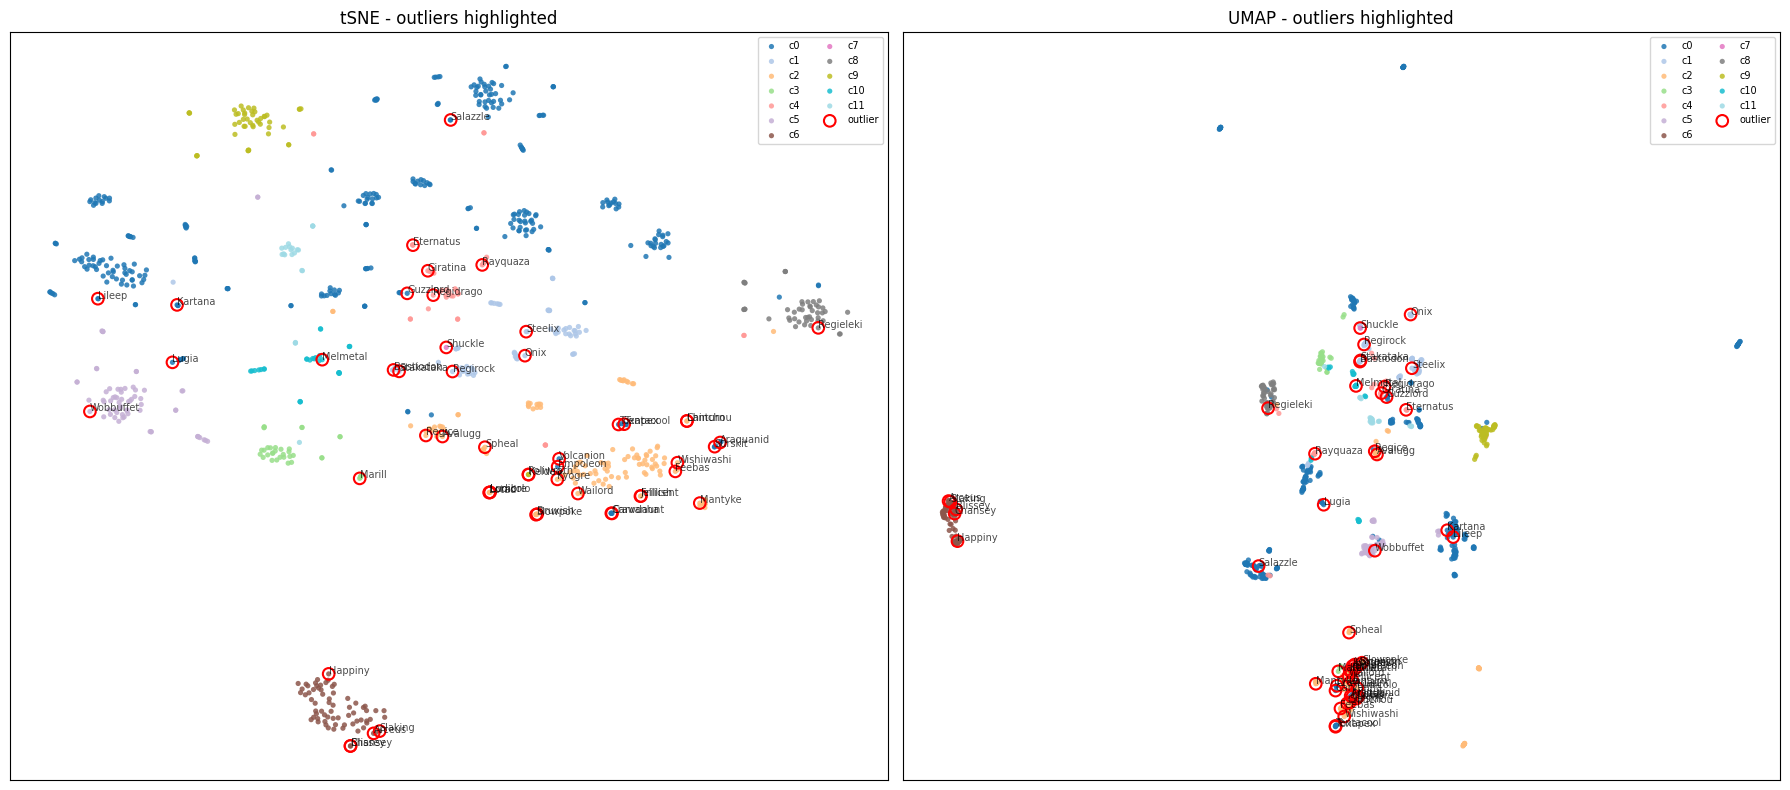

In [14]:
names = df["name"].tolist()
fig, axes = plt.subplots(1, n_panels, figsize=(9 * n_panels, 8))
if n_panels == 1:
    axes = [axes]
scatter(axes[0], tsne_emb, labels, "tSNE - outliers highlighted",
        names=names, outliers=outlier_idx)
if umap_emb is not None:
    scatter(axes[1], umap_emb, labels, "UMAP - outliers highlighted",
            names=names, outliers=outlier_idx)
plt.tight_layout()
plt.savefig(OUT / "embeddings_outliers.png", dpi=130)
plt.show()

### What makes them outliers?

Looking at the consensus list, a few patterns appear:

- **Unusual stat shapes** - Chansey / Blissey have huge HP but almost no defenses; Shuckle has extreme defenses but barely any offense. These don't fit any normal stat profile.
- **Unusual type combinations** - Water+Electric (Lanturn), Water+Fighting (Poliwrath), Bug+Rock (Shuckle) are rare combos that pull them away from the dense type clusters.
- **Unusual size** - very heavy (Steelix at ~400 kg) or very small Pokemon land in the tails of the size distribution.
- **Legendaries** - high stat totals plus rare type combos (e.g. Lugia: Psychic+Flying with stat total 680).

All four categories are exactly the kind of "different" we'd want an outlier method to catch.

## Task 5 - Discussion and Reflection

**What worked well**
- The block-based distance (stats + types + size) is interpretable and easy to tune. Swapping weights moves the clustering between "stat-driven" and "type-driven" in a predictable way.
- Average-linkage agglomerative on the precomputed matrix paired nicely with the silhouette sweep - no need to re-derive features for the clustering step.
- Multiple outlier methods cross-checking each other gave more confidence than any single method alone. The consensus list (Chansey, Blissey, Shuckle, Steelix, Lugia...) reads exactly like the Pokemon a fan would point at as "weird".

**Challenges**
- Choosing block weights is subjective. Type Jaccard is coarse (most Pokemon share at most 1-2 types), so it had to be downweighted relative to stats to avoid one giant blob per type.
- Height/weight have heavy tails; without `log1p` Wailord dominates the size distance and skews everything.
- Silhouette on a mixed distance is a relative signal, not an absolute one - "best k" really means "least bad k among the values we tried". The score also kept climbing with `k`, which can indicate the data is more of a continuum than well-separated clusters.
- HDBSCAN labeling ~40% of points as noise suggests the same: density is uneven, and many Pokemon live in sparse regions.

**If I had more time**
- **Use the thumbnails** - feed them through a pretrained CNN (e.g. CLIP or a small ResNet) and add an image-embedding block to the distance.
- **Tune block weights** with a grid search against a downstream metric like type-purity of clusters or recovery of known evolutionary families.
- **Compare more clustering algorithms** (spectral, OPTICS, k-medoids) and report stability across random seeds.
- **Per-generation analysis** - cluster within and across generations to see whether stat power creep shows up as drift in the embedding.